In [ ]:
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)

import jax.random as jrnd
import jax.numpy as jnp

import blackjax
import numpyro as npr
import numpyro.distributions as dist
import sys

import bamojax
from bamojax.base import Model

print('Python version:     ', sys.version)
print('Jax version:        ', jax.__version__)
print('BlackJax version:   ', blackjax.__version__)
print('Bamojax version:    ', bamojax.__version__)
print('Numpyro version:    ', npr.__version__)
print('Jax default backend:', jax.default_backend())
print('Jax devices:        ', jax.devices())

### plotting

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

SMALL_SIZE = 12
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

def pretty_axis(ax, fix_xaxis=True, fix_yaxis=True):
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False) 
    if fix_xaxis:
        ax.spines['bottom'].set_position(('axes', -0.05))
    if fix_yaxis:
        ax.spines['left'].set_position(('axes', -0.05))

#

Python version:      3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:48:23) [GCC 13.3.0]
Jax version:         0.9.2
BlackJax version:    1.2.5
Bamojax version:     0.3.13+0.ga55e0bd.dirty
Numpyro version:     0.19.0


Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/maxhin/anaconda3/envs/bamojax_numpyro/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 487, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/maxhin/anaconda3/envs/bamojax_numpyro/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
  File "/home/maxhin/anaconda3/envs/bamojax_numpyro/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:134: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Jax default backend: cpu
Jax devices:         [CpuDevice(id=0)]


# Tutorial 0: Becoming familiar with JAX

JAX offers an interface that is similar to NumPy, but it works differently in some small but important ways.

1. JAX is state-less. In practice, that means it does not have a global random number generator (important for Monte Carlo applications), but instead every function that does anything with random numbers requires a `key` parameter: `key = jax.random.PRNGKey(<seed>)`. This is essentially a random seed, which you initialize with a `<seed>` of your choice. Bonus: this makes your code easily reproducible! More explanation of this is provided here: https://docs.jax.dev/en/latest/random-numbers.html.
2. JAX has built-in primitives that replace standard Python basics like a `for` loop. This is very unintuitive initially, but leads to massive speed-ups, due to how JAX compiles code. It does have some requirements, such as that all code within the loop applies to arrays of the same sizes.
3. JAX doesn't 'easily' let you change elements of arrays in-place. Instead, your operation returns a copy of an entire array. If you do need to update element-wise, you write: `array = array.at[i].set(j)` to create a copy of the entire array that has `j` at location `i`.

For example, consider the code below:

In [ ]:
def square(x):
    return x**2


numbers = jnp.array([1, 2, 3, 4, 5])

# old skool:
new_numbers = jnp.zeros_like(numbers)
for i in range(len(numbers)):    
    new_numbers = new_numbers.at[i].set(numbers[i]**2)

# hip kids:
new_numbers2 = jax.vmap(square)(numbers)

# print to compare
print(new_numbers)
print(new_numbers2)

[ 1  4  9 16 25]
[ 1  4  9 16 25]


To get a little bit more familiar with both the concepts of random keys, and applying a function repeatedly in a `vmap` instead of a `for`-loop, we will here implement the Naive Monte Carlo algorithm for a simple model. Note that the goal of this workshop is not to become a JAX expert, but rather you need some JAX background to perform efficient BMA.

First, we are going to create some data from a Gaussian distribution: $y_i \sim \mathcal{N}(\mu, \sigma)$. We set $\mu=5.0$ and $\sigma=3.0$.

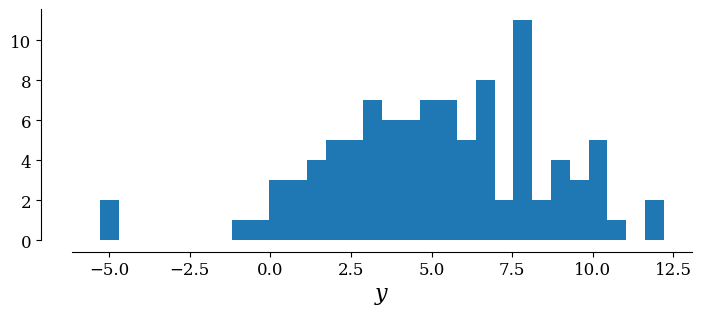

In [7]:
key = jrnd.PRNGKey(5678)
key, key_data, key_inference = jrnd.split(key, 3)

true_mean = 5.0
true_sd = 3.0

n = 100

y = dist.Normal(loc=true_mean, scale=true_sd).sample(key=key_data, sample_shape=(n, ))

plt.figure(figsize=(8, 3))
ax = plt.gca()
ax.hist(y, bins=30)
ax.set_xlabel(r'$y$')
pretty_axis(ax);

Now we need a model. Here, we assume that we know the true standard deviation $\sigma$, but not the mean $\mu$:

$$
    \begin{align*}  
        \mu &\sim \mathcal{N}(\hat{\mu}, \hat{\sigma}) &&\\
        y_i &\sim \mathcal{N}(\mu, \sigma) && i=1, \ldots, N
    \end{align*}
$$

We arbitrarily set $\hat{\mu}=0.0$ and $\hat{\sigma}=2.0$. Let's implement this in `bamojax`:

In [10]:
mu0 = 0.0
sd0 = 2.0

my_first_model = Model('Gaussian with unknown mean')
unknown_mean = my_first_model.add_node('mu', distribution=dist.Normal(loc=mu0, scale=sd0))
observations = my_first_model.add_node('y', distribution=dist.Normal, observations=y, parents=dict(loc=unknown_mean, scale=true_sd))

To quantify the fit of this model we can compute the (log) marginal likelihood: 

$$
\begin{align*}
    \log p(\mathbf{y})   &= \log \left(\int p(\mathbf{y}\mid \mu, \sigma) p(\mu) \, \text{d}\mu \right) && \\
                    &\approx \log\left(\frac{1}{S}\sum_{i=1}^S p\left(\mathbf{y}\mid \mu^{(i)}, \sigma \right) \right), && \mu^{(i)} \sim p(\mu) \\
                    &= \log\left(\sum_{i=1}^S p\left(\mathbf{y}\mid \mu^{(i)}, \sigma \right) \right) - \log S, && \mu^{(i)} \sim p(\mu) 
\end{align*}
$$

This discrete approximation of the integral _is_ the Naive Monte Carlo estimator. If we increase $S$, the quality of the approximation improves.

In the next tutorial we'll see different algorithms that can approximately do this, but for now we will implement the simplest baseline, Naive Monte Carlo. First, we need to create $S$ random samples from the prior. This requires $S$ JAX keys. 

1. Create a first key with `jrnd.PRNGKey(...)` and split it into $S$ subkeys.

2. Now use the `my_first_model.sample_prior` function to create $S$ samples from the prior _without_ using a Python `for` or `while` loop, but with a `vmap` instead.

3. Now use again a `vmap` and apply the `my_first_model.loglikelihood_fn` function to each sample. Note: calling `my_first_model.loglikelihood_fn()` returns this log-likelihood function (so if you want to apply it once you'd write: `my_first_model.loglikelihood_fn()(sample)`).

For this model, the exact log marginal likelihood is known, and it can be computed with the following code. 

4. Use the code below to compute the exact log marginal likelihood.

In [ ]:
def guk_lml(y, sd, mu0, sd0):
    # See https://www.cs.ubc.ca/~murphyk/Papers/bayesGauss.pdf
    y_bar = jnp.mean(y)
    n = len(y)
    return jnp.log(sd) - n/2*jnp.log(2*jnp.pi*sd**2) - 1/2*jnp.log(n*sd0**2 + sd**2) - jnp.sum(y**2) / (2*sd**2) - mu0 / (2*sd0**2) + (sd0**2 * n**2 * y_bar**2 / sd**2 + sd**2*mu0**2 / sd0**2 + 2*n*y_bar*mu0) / (2*(n*sd0**2 + sd**2))
    
#


We are almost ready to compute our approximation. However, note that we have obtained the _log_ likelihood for each sample, whereas the Naive Monte Carlo estimate is the mean of the likelihoods themselves. To get the approximate log marginal likelihood, we need to take the __log__ of the __sum__ of the __exponent__ of these loglikelihoods. Doing this naively is not numerically stable, but we can instead use the `logsumexp` function, which does this for you in a smarter way.

5. Use the `jax.scipy.logsumexp` function to compute your approximation of the log marginal likelihood.

In [ ]:
from jax.scipy.special import logsumexp


6. Make a histogram of your loglikelihoods for each sample, and plot vertical lines for the exact answer and your Naive Monte Carlo estimate. Try a couple of different values for $S$. What seems a reasonable number?

Note: you may find that with not-so-big $S$ your estimate is pretty close (good job!). Note that this does not _at all_ scale to models with more parameters!

Try having your approximation match up to 2 decimal places!